In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [4]:
df_test

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


In [5]:
df_train.isna().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [6]:
df_test.isna().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [8]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [10]:
set(df_test['Age']).difference(set(df_train['Age']))

set()

In [11]:
df_train['Sex'] = label.fit_transform(df_train['Sex'])
df_test['Sex'] = label.fit_transform(df_test['Sex'])


<Axes: xlabel='Sex'>

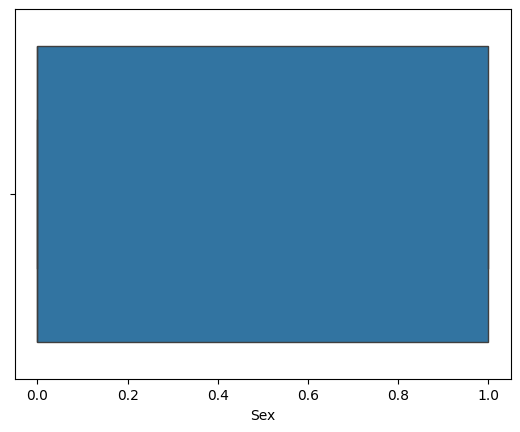

In [20]:
sns.boxplot(x = df_train['Sex'])

<Axes: xlabel='Age'>

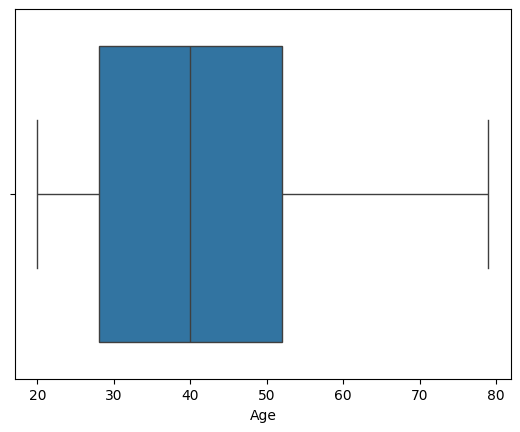

In [21]:
sns.boxplot(x = df_train['Age'])

<Axes: xlabel='Height'>

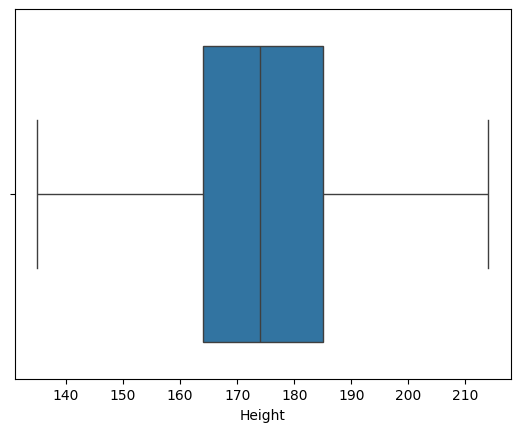

In [22]:
sns.boxplot(x = df_train['Height'])

<Axes: xlabel='Weight'>

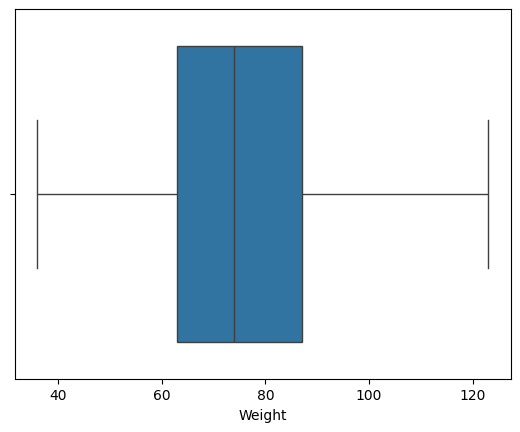

In [23]:
sns.boxplot(x = df_train['Weight'])

<Axes: xlabel='Duration'>

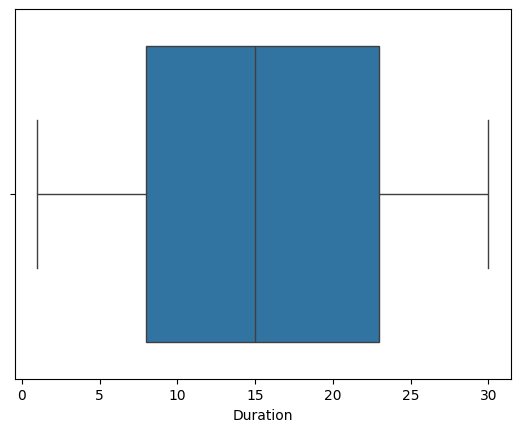

In [24]:
sns.boxplot(x = df_train['Duration'])

<Axes: xlabel='Heart_Rate'>

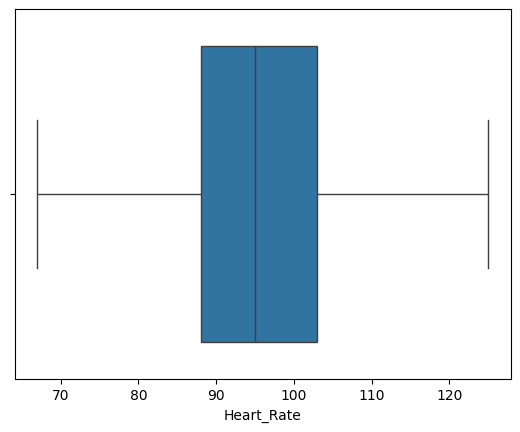

In [25]:
sns.boxplot(x = df_train['Heart_Rate'])

<Axes: xlabel='Body_Temp'>

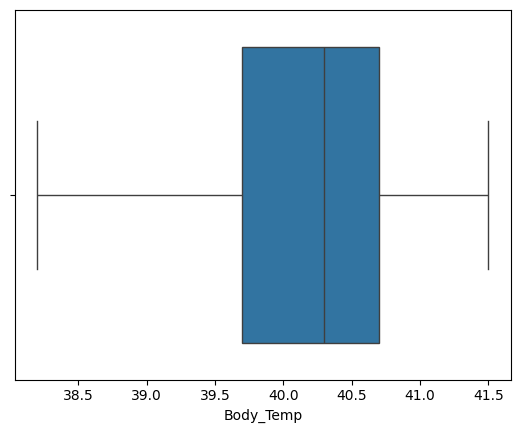

In [29]:
sns.boxplot(x = df_train['Body_Temp'])

In [28]:
def replace_outliers_with_median(df_train, col):
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df_train[col].median()
    df_train.loc[(df_train[col] < lower) | (df_train[col] > upper), col] = median


num_cols = df_train.select_dtypes(include=['float64']).columns

for col in num_cols:
    replace_outliers_with_median(df_train, col)


In [30]:
X_train = df_train.drop('Calories', axis=1)
y_train = df_train['Calories']
X_test = df_test.copy()

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [32]:
poly = PolynomialFeatures()
model = LinearRegression()

In [33]:
pipe = Pipeline([('poly',poly),('model',model)])

In [34]:
params = {
    'poly__degree':[1, 2, 3, 4,5,6],
    'poly__include_bias':[False]
}

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
final_model = GridSearchCV(pipe, params , cv = 3, verbose = 2)

In [37]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.1s
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.0s
[CV] END ...........poly__degree=1, poly__include_bias=False; total time=   0.0s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   0.7s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   0.6s
[CV] END ...........poly__degree=2, poly__include_bias=False; total time=   0.6s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   3.7s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   3.6s
[CV] END ...........poly__degree=3, poly__include_bias=False; total time=   3.5s
[CV] END ...........poly__degree=4, poly__include_bias=False; total time=   7.8s
[CV] END ...........poly__degree=4, poly__include_bias=False; total time=   7.7s
[CV] END ...........poly__degree=4, poly__include

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...], 'poly__include_bias': [False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [38]:
final_model.best_score_

np.float64(0.9954627942640405)

In [39]:
final_model.best_params_

{'poly__degree': 6, 'poly__include_bias': False}

In [41]:
y_pred = final_model.predict(X_test)

In [42]:
df_sub = pd.read_csv('sample_submission.csv')

In [43]:
df_sub.to_csv('sub.csv',index = False,index_label = False)

In [44]:
df_sub

,id,Calories
0,750000,88.283
1,750001,88.283
2,750002,88.283
3,750003,88.283
4,750004,88.283
...,...,...
249995,999995,88.283
249996,999996,88.283
249997,999997,88.283
249998,999998,88.283
